# 01 — Exploratory Data Analysis (EDA)

**TFM: Hydrological modelling of the Sant Miquel basin — water-level prediction at STM08 (Sa Marjal).**

Objectives (Phase 1 of `docs/plan_TFM.md`):

1. Load all clean station CSVs and quantify missing-data rates per station and variable.
2. Visualize the complete time series of each station.
3. Compute lagged cross-correlations between each predictor and STM08 (best predictors, optimal lag → first estimate of the basin response time).
4. Identify and characterize historical flood events with a **reproducible, literature-based rule**.
5. Analyze seasonality (Mediterranean regime: wet vs. dry season).

> **⚠ Preliminary phase.** This notebook is a *first look* at the data. Because of the
> missing-data periods documented below, every result — in particular the automatic
> event identification — must be interpreted with caution: data gaps can **split** a
> real event into several pieces or **hide** events entirely. Events overlapping gaps
> are explicitly flagged, and no result here should be treated as definitive until the
> preprocessing phase (02) consolidates the 10-min grid and the gap treatment.

In [1]:
# --- Imports & configuration -------------------------------------------------
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Resolve the repository root by walking up until data/clean is found
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "data" / "clean").is_dir():
        ROOT = p
        break
CLEAN = ROOT / "data" / "clean"
FIGDIR = ROOT / "results" / "figures" / "eda"
FIGDIR.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

HYDRO = ["STM03", "STM04", "STM05", "STM06", "STM07", "STM08"]  # water level / discharge
METEO = ["STM01", "STM02"]                                     # precip + temperature
AEMET = ["B013X", "B605X", "B691Y"]                            # hourly precip
TARGET = "STM08"

# Common analysis window (intersection of all sources, plan_TFM.md §2)
T0 = pd.Timestamp("2014-09-26")
T1 = pd.Timestamp("2026-07-02")
# End of the *validated* (xlsx-derived) period: the DB extension starts on
# 2025-07-23 for STM03 (later for the rest). Quantitative analyses below are
# restricted to this window — see the data-quality findings in §3.1.
T1_HIST = pd.Timestamp("2025-07-22")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "lines.linewidth": 0.8,
})

def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"saved {path.relative_to(ROOT)}")

print(f"Repository root: {ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Repository root: /mnt/c/Users/Joan/Documents/TFM
pandas 3.0.5 | numpy 2.5.1


## 1. Station inventory

The clean CSVs come with companion `*_metadata.txt` files (start/end dates, sampling-frequency
periods, cleaning notes) and there is a sensor registry (`data/sensors_information/sensors_information.csv`)
with coordinates, altitude and instrument models. Merging both gives the station inventory table
(draft of the *Stations table* required by the advisor).

In [2]:
# --- Parse the metadata files -------------------------------------------------
def parse_metadata(code):
    txt = (CLEAN / f"{code}_metadata.txt").read_text(encoding="utf-8")
    def grab(pattern, default=None):
        m = re.search(pattern, txt)
        return m.group(1).strip() if m else default
    freqs = re.findall(r"^\s+(\d+) min:", txt, flags=re.M)
    qm = re.search(r"(\d[\d ]*\d|\d) registro\(s\) con quality != 0", txt)
    return {
        "code": code,
        "name": grab(r"ESTACIÓN:\s*\w+ - (.+)"),
        "type": grab(r"TIPO: (.+)"),
        "t0": grab(r"T0 \(primer registro\):\s*(.+)"),
        "t_end": grab(r"T_end \(último registro\):\s*(.+)"),
        "freq_periods": " → ".join(f"{f} min" for f in freqs) or grab(r"PERÍODOS.*\n\s+(.+?)\s", default="60 min"),
        "total_rows": int(grab(r"Total de filas exportadas:\s*(\d+)", "0")),
        "quality_nonzero_records": int(qm.group(1).replace(" ", "")) if qm else 0,
    }

inventory = pd.DataFrame([parse_metadata(c) for c in HYDRO + METEO + AEMET])

# Coordinates / altitude from the sensor registry (one row per station)
sensors = pd.read_csv(ROOT / "data" / "sensors_information" / "sensors_information.csv")
sensors1 = sensors.sort_values("variable_code").drop_duplicates("station_code")
inventory = inventory.merge(
    sensors1[["station_code", "latitude", "longitude", "z_utm", "instrument_model"]],
    left_on="code", right_on="station_code", how="left",
).drop(columns="station_code")
inventory.rename(columns={"z_utm": "altitude_m"}, inplace=True)
inventory

,code,name,type,t0,t_end,freq_periods,total_rows,quality_nonzero_records,latitude,longitude,altitude_m,instrument_model
0,STM03,Es Fangar,Hidrológica,2012-10-01 00:05:59,2026-08-05 11:30:00,15 min → 10 min,595356,51336,NaN,NaN,NaN,NaN
1,STM04,Gabelli,Hidrológica,2012-12-06 09:30:00,2026-08-05 23:55:00,15 min → 10 min,587756,0,39.795811,2.965730,50.149,CS451
2,STM05,Monnàber,Hidrológica,2012-10-01 00:14:59,2026-08-05 23:55:00,15 min → 10 min,569422,16914,39.791821,2.963273,51.302,OTT PLS
3,STM06,Sant Miquel,Hidrológica,2012-10-01 00:15:00,2026-08-05 23:55:00,15 min → 10 min,570087,0,39.793333,2.965656,47.301,CS451
4,STM07,Búger,Hidrológica,2012-10-01 00:15:00,2026-08-05 23:55:00,15 min → 10 min,563449,0,39.752075,2.978666,55.359,CS451
5,STM08,Sa Marjal,Hidrológica,2013-03-04 12:00:00,2026-08-05 23:55:00,15 min → 10 min,563734,0,39.790641,3.037428,5.589,CS451
6,STM01,Coll des Telègraf,Meteorológica,2012-11-30 12:00:00,2026-08-05 10:20:00,15 min → 10 min,532894,0,39.811079,2.853346,1105.400,OTT Pluvio L
7,STM02,Míner Gran,Meteorológica,2014-09-26 18:30:00,2026-08-05 11:20:00,15 min → 10 min,481211,1,39.832982,2.954354,558.950,15189 H - 0.2mm
8,B013X,Lluc,Meteorológica (precipitación horaria),1993-04-16 01:00:00,2026-08-05 23:00:00,60 min,260424,582,39.823338,2.885828,490.000,NaN
9,B605X,Muro-S'albufera,Meteorológica (precipitación horaria),2005-04-12 01:00:00,2026-08-05 23:00:00,60 min,177226,584,39.796665,3.104721,2.000,NaN


saved results/figures/eda/station_map.png


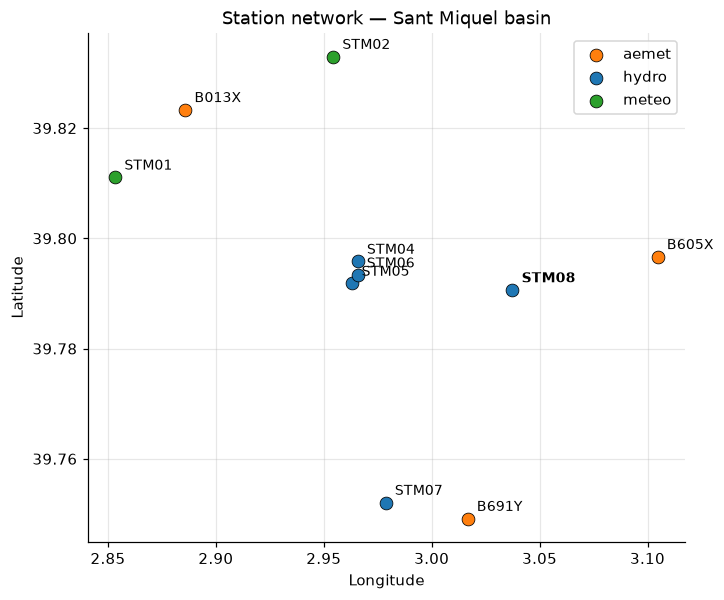

,code,name,type,dist_to_STM08_km,altitude_m
0,STM03,Es Fangar,Hidrológica,NaN,NaN
1,STM04,Gabelli,Hidrológica,6.15,50.149
2,STM05,Monnàber,Hidrológica,6.34,51.302
3,STM06,Sant Miquel,Hidrológica,6.14,47.301
4,STM07,Búger,Hidrológica,6.60,55.359
5,STM08,Sa Marjal,Hidrológica,0.00,5.589
6,STM01,Coll des Telègraf,Meteorológica,15.89,1105.400
7,STM02,Míner Gran,Meteorológica,8.52,558.950
8,B013X,Lluc,Meteorológica (precipitación horaria),13.45,490.000
9,B605X,Muro-S'albufera,Meteorológica (precipitación horaria),5.79,2.000


In [3]:
# --- Station map and distance to STM08 ----------------------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

tgt = inventory.loc[inventory.code == TARGET].iloc[0]
inventory["dist_to_STM08_km"] = haversine_km(
    tgt.latitude, tgt.longitude, inventory.latitude, inventory.longitude).round(2)

kind = inventory.code.map(lambda c: "hydro" if c in HYDRO else ("meteo" if c in METEO else "aemet"))
colors = {"hydro": "tab:blue", "meteo": "tab:green", "aemet": "tab:orange"}

fig, ax = plt.subplots(figsize=(7, 6))
for k, grp in inventory.groupby(kind):
    ax.scatter(grp.longitude, grp.latitude, s=70, c=colors[k], label=k, zorder=3,
               edgecolors="k", linewidths=0.5)
for _, r in inventory.iterrows():
    ax.annotate(r.code, (r.longitude, r.latitude), textcoords="offset points",
                xytext=(6, 5), fontsize=9,
                fontweight="bold" if r.code == TARGET else "normal")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Station network — Sant Miquel basin")
ax.legend()
savefig(fig, "station_map.png")
plt.show()

inventory[["code", "name", "type", "dist_to_STM08_km", "altitude_m"]]

## 2. Data loading & integrity checks

Load the 11 clean CSVs, verify basic integrity (duplicated timestamps, monotonicity) and
empirically confirm the sampling-frequency periods declared in the metadata
(15 min → 10 min → 5 min for STM stations; 60 min for AEMET).

> **🔎 Data-quality finding (STM02).** 73 cells of `PRECIP_mm` in `STM02.csv` contain **raw Excel
> formula strings** (`=0.2*N` or `=N*0.2`, i.e. 0.2 mm × N tipping-bucket counts) instead of
> numbers — the cleaning script nullified formula strings for `TEMP_C` but not for `PRECIP_mm`
> (see `scripts/cleaning/clean_STM02.py`). These are *recoverable* observations, so the loader
> below evaluates them (`0.2 × N` mm) and reports the count. **Action item for Phase 2:** fix the
> cleaning script and regenerate the CSV so the recovery happens upstream.
>
> **🔎 Data-quality finding (timestamps).** A few rows have empty/invalid timestamps (e.g. 4 in
> STM03) and several stations contain **duplicated timestamps** (hundreds to thousands in
> STM01/STM03/STM05). The loader drops invalid-timestamp rows and keeps the first occurrence of
> each duplicate; the counts are reported in the integrity table. Whether duplicates are true
> double measurements or export artifacts should be revisited in Phase 2.

In [4]:
# --- Load all stations ---------------------------------------------------------
FORMULA_RE = re.compile(r"^=(?:0\.2\*(\d+)|(\d+)\*0\.2)$")

def _coerce_numeric(s):
    """Coerce to float64; recover raw tipping-bucket formulas '=0.2*N' / '=N*0.2'
    (0.2 mm x N bucket tips)."""
    arr = pd.to_numeric(s, errors="coerce").to_numpy(dtype="float64", na_value=np.nan).copy()
    if not pd.api.types.is_numeric_dtype(s):
        ext = s.astype("string").str.extract(FORMULA_RE)
        tips = ext[0].fillna(ext[1])
        rec = pd.to_numeric(tips, errors="coerce").to_numpy(dtype="float64", na_value=np.nan) * 0.2
        m = np.isnan(arr) & ~np.isnan(rec)
        if m.any():
            print(f"   WARNING {s.name}: recovered {int(m.sum())} raw Excel tipping-bucket formulas")
            arr[m] = rec[m]
    return pd.Series(arr, index=s.index, name=s.name)

def load_station(code):
    df = pd.read_csv(CLEAN / f"{code}.csv", parse_dates=["TIMESTAMP"], low_memory=False)
    df = df.set_index("TIMESTAMP").sort_index()
    for col in df.columns:
        df[col] = _coerce_numeric(df[col])
    return df

LOAD_STATS = {}

def load_station(code):
    df = pd.read_csv(CLEAN / f"{code}.csv", low_memory=False)
    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")
    n_raw = len(df)
    n_nat = int(df["TIMESTAMP"].isna().sum())
    df = df.dropna(subset=["TIMESTAMP"]).set_index("TIMESTAMP").sort_index()
    n_dup = int(df.index.duplicated().sum())
    df = df[~df.index.duplicated(keep="first")]
    LOAD_STATS[code] = {"rows_raw": n_raw, "invalid_ts": n_nat, "duplicated_ts": n_dup}
    if n_nat or n_dup:
        print(f"   WARNING {code}: dropped {n_nat} rows with empty/invalid timestamp, "
              f"{n_dup} duplicated timestamps (kept first occurrence)")
    for col in df.columns:
        df[col] = _coerce_numeric(df[col])
    return df

data = {c: load_station(c) for c in HYDRO + METEO + AEMET}

# Hydro CSVs now only contain HEIGHT_m (v2 format).  Ensure DISCHARGE/VOLUME/LOAD
# columns exist (filled with NaN) so downstream code that references them does not
# crash.  Rating curves will be applied in a later phase.
_expected_cols = ["DISCHARGE_m3s", "VOLUME_m3", "LOAD_kg"]
for c in HYDRO:
    for col in _expected_cols:
        if col not in data[c].columns:
            data[c][col] = np.nan

summary = pd.DataFrame({
    c: {
        "rows_raw": LOAD_STATS[c]["rows_raw"],
        "invalid_ts": LOAD_STATS[c]["invalid_ts"],
        "duplicated_ts": LOAD_STATS[c]["duplicated_ts"],
        "rows_final": len(df),
        "t0": df.index.min(),
        "t_end": df.index.max(),
        "variables": ", ".join(df.columns),
    }
    for c, df in data.items()
}).T
summary

   WARNING STM03: dropped 4 rows with empty/invalid timestamp, 1712 duplicated timestamps (kept first occurrence)


   WARNING STM04: dropped 0 rows with empty/invalid timestamp, 6 duplicated timestamps (kept first occurrence)


   WARNING STM05: dropped 0 rows with empty/invalid timestamp, 674 duplicated timestamps (kept first occurrence)


   WARNING STM06: dropped 0 rows with empty/invalid timestamp, 44 duplicated timestamps (kept first occurrence)


   WARNING STM07: dropped 0 rows with empty/invalid timestamp, 11 duplicated timestamps (kept first occurrence)


   WARNING STM08: dropped 0 rows with empty/invalid timestamp, 1 duplicated timestamps (kept first occurrence)


   WARNING STM01: dropped 0 rows with empty/invalid timestamp, 441 duplicated timestamps (kept first occurrence)


   WARNING PRECIP_mm: recovered 73 raw Excel tipping-bucket formulas


,rows_raw,invalid_ts,duplicated_ts,rows_final,t0,t_end,variables
STM03,595360,4,1712,593644,2012-10-01 00:05:59,2026-08-05 11:30:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM04,587756,0,6,587750,2012-12-06 09:30:00,2026-08-05 23:55:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM05,569422,0,674,568748,2012-10-01 00:14:59,2026-08-05 23:55:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM06,570087,0,44,570043,2012-10-01 00:15:00,2026-08-05 23:55:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM07,563449,0,11,563438,2012-10-01 00:15:00,2026-08-05 23:55:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM08,563734,0,1,563733,2013-03-04 12:00:00,2026-08-05 23:55:00,"HEIGHT_m, DISCHARGE_m3s, VOLUME_m3, LOAD_kg"
STM01,532894,0,441,532453,2012-11-30 12:00:00,2026-08-05 10:20:00,"PRECIP_mm, TEMP_C"
STM02,481211,0,0,481211,2014-09-26 18:30:00,2026-08-05 11:20:00,"PRECIP_mm, TEMP_C"
B013X,260424,0,0,260424,1993-04-16 01:00:00,2026-08-05 23:00:00,PRECIP_mm
B605X,177226,0,0,177226,2005-04-12 01:00:00,2026-08-05 23:00:00,PRECIP_mm


In [5]:
# --- Empirical sampling intervals vs. declared frequency periods ---------------
for c, df in data.items():
    d = df.index.to_series().diff().dropna()
    vc = d.value_counts()
    top = ", ".join(f"{str(k)}: {100*v/len(d):.1f}%" for k, v in vc.head(3).items())
    print(f"{c:6s} top intervals → {top}")

STM03  top intervals → 0 days 00:10:00: 22.9%, 0 days 00:15:00: 18.1%, 0 days 00:15:01: 18.0%
STM04  top intervals → 0 days 00:10:00: 24.2%, 0 days 00:15:00: 18.6%, 0 days 00:15:01: 18.5%
STM05  top intervals → 0 days 00:10:00: 25.2%, 0 days 00:15:00: 18.4%, 0 days 00:15:01: 18.3%
STM06  top intervals → 0 days 00:15:00: 53.9%, 0 days 00:10:00: 32.0%, 0 days 00:05:00: 13.9%
STM07  top intervals → 0 days 00:15:00: 51.2%, 0 days 00:10:00: 34.6%, 0 days 00:05:00: 7.4%
STM08  top intervals → 0 days 00:15:00: 56.4%, 0 days 00:10:00: 35.6%, 0 days 00:05:00: 7.8%
STM01  top intervals → 0 days 00:15:00: 60.5%, 0 days 00:10:00: 39.1%, 0 days 00:20:00: 0.1%
STM02  top intervals → 0 days 00:15:00: 55.3%, 0 days 00:10:00: 44.6%, 0 days 00:15:01: 0.1%
B013X  top intervals → 0 days 01:00:00: 99.8%, 1 days 01:00:00: 0.1%, 2 days 01:00:00: 0.0%
B605X  top intervals → 0 days 01:00:00: 100.0%, 1 days 01:00:00: 0.0%, 0 days 02:00:00: 0.0%
B691Y  top intervals → 0 days 01:00:00: 99.9%, 0 days 02:00:00: 0.0

## 3. Missing-data analysis

Two distinct issues are quantified here:

1. **NaN cells** in the clean CSVs (empty exports from the source files / unavailable variables).
2. **Time gaps** — periods with no records at all or long runs of NaNs.

> **⚠ Quality flags are *not* preserved in the clean CSVs.** The extension scripts only
> *counted* records with `quality != 0` (STM03 ≈ 45 k, STM05 ≈ 3 k, each AEMET ≈ 582 records,
> see the inventory table above). The meaning of the flag values and their treatment
> (removal / correction / imputation) is an **open action item** for the preprocessing
> phase — the advisor explicitly requires the flags to be preserved and documented.

In [6]:
# --- Null rates per station and variable ---------------------------------------
rows = []
for c, df in data.items():
    for col in df.columns:
        n = int(df[col].isna().sum())
        rows.append({"station": c, "variable": col, "nulls": n,
                     "null_%": round(100 * n / len(df), 2)})
null_tbl = pd.DataFrame(rows)
null_tbl.pivot_table(index="station", columns="variable", values="null_%")

variable,DISCHARGE_m3s,HEIGHT_m,LOAD_kg,PRECIP_mm,TEMP_C,VOLUME_m3
station,,,,,,
B013X,NaN,NaN,NaN,0.07,NaN,NaN
B605X,NaN,NaN,NaN,0.00,NaN,NaN
B691Y,NaN,NaN,NaN,0.00,NaN,NaN
STM01,NaN,NaN,NaN,0.05,11.03,NaN
STM02,NaN,NaN,NaN,0.27,28.58,NaN
STM03,100.0,14.63,100.0,NaN,NaN,100.0
STM04,100.0,1.50,100.0,NaN,NaN,100.0
STM05,100.0,7.30,100.0,NaN,NaN,100.0
STM06,100.0,0.11,100.0,NaN,NaN,100.0


saved results/figures/eda/null_rate_heatmap_height.png


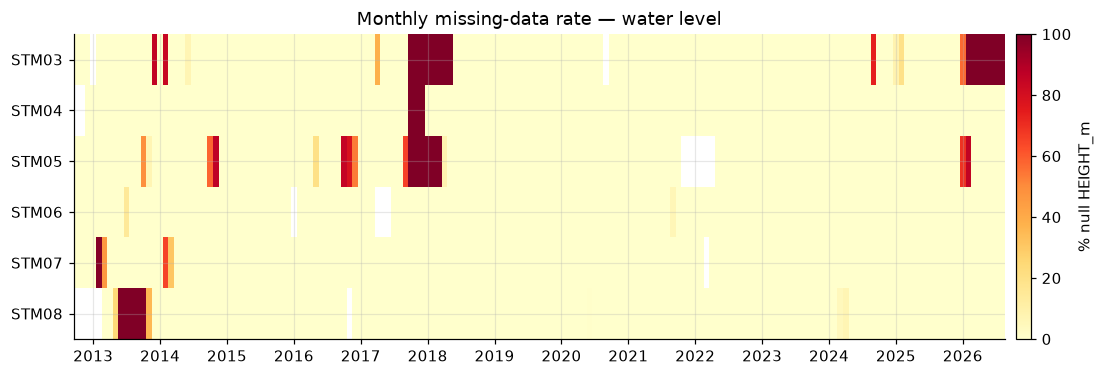

In [7]:
# --- Monthly null-rate heatmap for HEIGHT_m (hydrological stations) ------------
mat = pd.DataFrame({
    c: data[c]["HEIGHT_m"].isna().astype(float).groupby(
        data[c].index.to_period("M")).mean() * 100
    for c in HYDRO
}).sort_index()

fig, ax = plt.subplots(figsize=(13, 3.6))
vals = np.ma.masked_invalid(mat.T.to_numpy())
im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
xt = [i for i, p in enumerate(mat.index) if p.month == 1]
ax.set_xticks(xt); ax.set_xticklabels([mat.index[i].year for i in xt])
ax.set_yticks(range(len(mat.columns))); ax.set_yticklabels(mat.columns)
fig.colorbar(im, ax=ax, label="% null HEIGHT_m", pad=0.01)
ax.set_title("Monthly missing-data rate — water level")
savefig(fig, "null_rate_heatmap_height.png")
plt.show()

In [8]:
# --- Gap analysis (runs of consecutive NaNs) ------------------------------------
def find_gaps(s):
    """Runs of consecutive NaNs; span measured between the surrounding valid stamps."""
    isn = s.isna().to_numpy()
    idx = s.index
    if not isn.any():
        return pd.DataFrame(columns=["gap_start", "gap_end", "n_missing",
                                     "prev_valid", "next_valid", "span_h"])
    edges = np.diff(isn.astype(np.int8))
    starts = list(np.where(edges == 1)[0] + 1)
    ends = list(np.where(edges == -1)[0] + 1)
    if isn[0]:
        starts = [0] + starts
    if isn[-1]:
        ends = ends + [len(isn)]
    rows = [{
        "gap_start": idx[a], "gap_end": idx[b - 1], "n_missing": b - a,
        "prev_valid": idx[a - 1] if a > 0 else pd.NaT,
        "next_valid": idx[b] if b < len(idx) else pd.NaT,
    } for a, b in zip(starts, ends)]
    g = pd.DataFrame(rows)
    g["span_h"] = (g["next_valid"] - g["prev_valid"]).dt.total_seconds() / 3600
    return g.sort_values("span_h", ascending=False).reset_index(drop=True)

gaps08 = find_gaps(data[TARGET]["HEIGHT_m"])
print(f"STM08 HEIGHT_m: {len(gaps08)} NaN runs")
print("\nLongest 10 gaps:")
gaps08.head(10)

STM08 HEIGHT_m: 32 NaN runs

Longest 10 gaps:


,gap_start,gap_end,n_missing,prev_valid,next_valid,span_h
0,2013-06-30 00:15:00,2013-09-08 14:00:00,6775,2013-06-30 00:00:00,2013-09-08 14:15:00,1694.250000
1,2013-09-08 14:30:00,2013-11-11 13:00:04,6139,2013-09-08 14:15:00,2013-11-11 13:15:04,1535.001111
2,2013-05-24 09:45:00,2013-06-13 13:00:00,1933,2013-05-24 09:30:00,2013-06-13 13:15:00,483.750000
3,2013-06-13 13:45:00,2013-06-29 23:45:00,1577,2013-06-13 13:30:00,2013-06-30 00:00:00,394.500000
4,2020-06-17 15:15:00,2020-06-17 18:45:00,15,2020-06-17 15:00:00,2020-06-18 11:00:00,20.000000
5,2024-03-06 16:40:00,2024-03-07 06:40:00,85,2024-03-06 16:30:00,2024-03-07 06:50:00,14.333333
6,2024-03-07 19:20:00,2024-03-08 07:10:00,72,2024-03-07 19:10:00,2024-03-08 07:20:00,12.166667
7,2024-04-13 20:30:00,2024-04-14 05:30:00,55,2024-04-13 20:20:00,2024-04-14 05:40:00,9.333333
8,2024-04-12 21:20:00,2024-04-13 05:30:00,50,2024-04-12 21:10:00,2024-04-13 05:40:00,8.500000
9,2024-04-23 00:20:00,2024-04-23 07:00:00,41,2024-04-23 00:10:00,2024-04-23 07:10:00,7.000000


saved results/figures/eda/stm08_gap_distribution.png


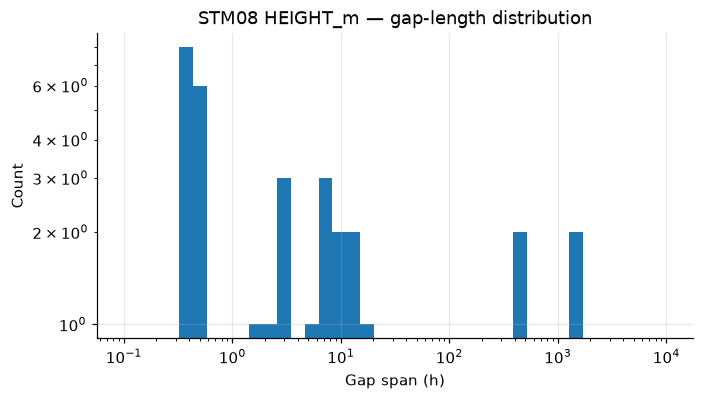

Intermittency stats (last column = PRECIP == 0 for meteo stations):


,H ≤ 0.01 m (% valid),Q == 0 (% valid),Q ≤ 0.01 (% valid)
station,,,
STM03,49.4,NaN,NaN
STM04,67.6,NaN,NaN
STM05,67.5,NaN,NaN
STM06,65.1,NaN,NaN
STM07,70.9,NaN,NaN
STM08,78.1,NaN,NaN
STM01,96.7,NaN,NaN
STM02,97.4,NaN,NaN
B013X,93.4,NaN,NaN


In [9]:
# --- Gap-length distribution + intermittency (zero-inflation) -------------------
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(gaps08["span_h"].clip(upper=24 * 365), bins=np.logspace(-1, 4, 40), color="tab:blue")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Gap span (h)"); ax.set_ylabel("Count")
ax.set_title("STM08 HEIGHT_m — gap-length distribution")
savefig(fig, "stm08_gap_distribution.png")
plt.show()

rows = []
for c in HYDRO:
    df = data[c]
    h = df["HEIGHT_m"]
    rows.append({
        "station": c,
        "H ≤ 0.01 m (% valid)": round(100 * (h <= 0.01).sum() / h.notna().sum(), 1),
    })
for c in METEO + AEMET:
    p = data[c]["PRECIP_mm"]
    rows.append({"station": c, "Q == 0 (% valid)": None, "Q ≤ 0.01 (% valid)": None,
                 "H ≤ 0.01 m (% valid)": round(100 * (p == 0).sum() / p.notna().sum(), 1)})
print("Intermittency stats (last column = PRECIP == 0 for meteo stations):")
pd.DataFrame(rows).set_index("station")

### 3.1 Physical-plausibility screening (water level & discharge)

> **🔎 Major finding — the DB-extension period is raw, unharmonized and unvalidated.**
> In the historical (xlsx-derived, validated) period no station exceeds **3.5 m** of water level
> (STM08 record: 2.83 m during the Dec-2016 flood) and discharge stays within 0–90 m³/s. In the
> **DB-extension period** (2025-07-23 / 2026-02-17 onward, depending on the station) the level
> series contain spikes up to **177 m** (STM03), systematic **negative plateaus** (STM05 sits at
> −1.0), suspicious **regular daily sawtooth oscillations of several meters** (STM08, STM04) and
> apparent station-specific datum shifts — 100 % of the out-of-range values occur in 2025–2026,
> and the in-range extension values are not trustworthy either. This is consistent with the
> un-applied `quality` flags (§3 action item) and with the plan's note that the extension provides
> `HEIGHT_m` only.
>
> **Consequences for this EDA:**
> 1. A plausibility screening is applied for display purposes: keep −0.5 m ≤ `HEIGHT_m` ≤ 5 m and
>    0 ≤ `DISCHARGE_m3s` ≤ 200 m³/s (rest → NaN).
> 2. **All quantitative analyses (cross-correlations, event identification, seasonality) are
>    restricted to the validated historical window 2014-09-26 → 2025-07-22.** The extension period
>    is shown only descriptively. **Critical action item for Phase 2:** harmonize units/datums and
>    apply the `quality` flags to the extension data before any modeling use (coordinate with the
>    data provider — advisor requirement).

Out-of-range screening (H_LIM = [−0.5, 5] m):
         H_out_of_range  %_of_valid_H  %_of_them_in_extension
station                                                      
STM03             26997          5.33                   100.0
STM04             17412          3.01                   100.0
STM05             50959          9.67                   100.0
STM06             28978          5.09                   100.0
STM07             15078          2.71                   100.0
STM08              7415          1.36                   100.0


saved results/figures/eda/extension_raw_levels.png


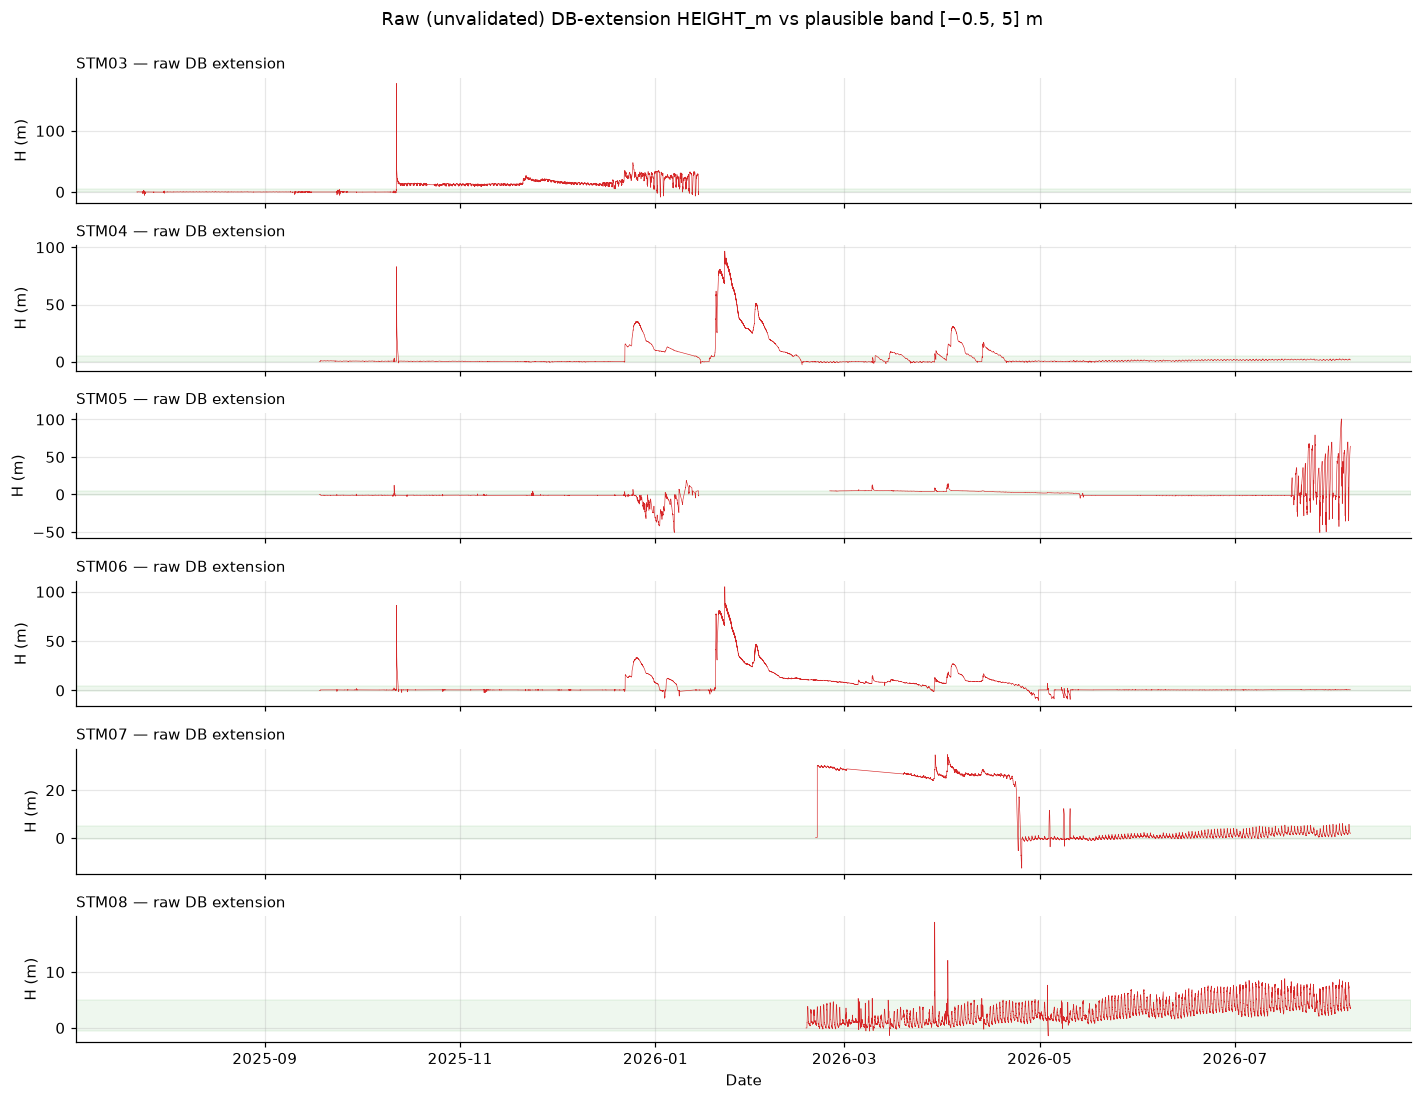

In [10]:
# --- Plausibility screening ------------------------------------------------------
H_LIM = (-0.5, 5.0)   # plausible water-level range (m)
EXT_START = {"STM03": "2025-07-23", "STM04": "2025-09-18", "STM05": "2025-09-18",
             "STM06": "2025-09-18", "STM07": "2026-02-20", "STM08": "2026-02-17"}

rows, HC = [], {}
for c in HYDRO:
    h = data[c]["HEIGHT_m"]
    bad_h = h.notna() & ~h.between(*H_LIM)
    in_ext = h.index >= pd.Timestamp(EXT_START[c])
    HC[c] = h.where(~bad_h)  # screened level (used downstream)
    rows.append({
        "station": c,
        "H_out_of_range": int(bad_h.sum()),
        "%_of_valid_H": round(100 * bad_h.sum() / h.notna().sum(), 2),
        "%_of_them_in_extension": round(100 * (bad_h & in_ext).sum() / max(bad_h.sum(), 1), 1),
    })
print("Out-of-range screening (H_LIM = [−0.5, 5] m):")
print(pd.DataFrame(rows).set_index("station").to_string())

# Visual diagnostic: raw extension-period levels (spikes, plateaus, sawtooth artifacts)
fig, axes = plt.subplots(len(HYDRO), 1, figsize=(13, 10), sharex=True)
for ax, c in zip(axes, HYDRO):
    ext = data[c]["HEIGHT_m"].loc[pd.Timestamp(EXT_START[c]):]
    ax.plot(ext.index, ext, lw=0.4, color="tab:red")
    ax.axhspan(*H_LIM, color="tab:green", alpha=0.08)
    ax.set_ylabel("H (m)"); ax.set_title(f"{c} — raw DB extension", loc="left", fontsize=10)
axes[-1].set_xlabel("Date")
fig.suptitle("Raw (unvalidated) DB-extension HEIGHT_m vs plausible band [−0.5, 5] m", y=0.995)
fig.tight_layout()
savefig(fig, "extension_raw_levels.png")
plt.show()

## 4. Full time-series visualization

Complete series for every station. The mixed sampling frequencies (15/10/5 min) are visible as
changes in line density; the DB-extension period (only `HEIGHT_m`) is visible as empty
`DISCHARGE_m3s` / `VOLUME_m3` / `LOAD_kg` in the hydro stations after ~2025.

saved results/figures/eda/hydro_height_full.png


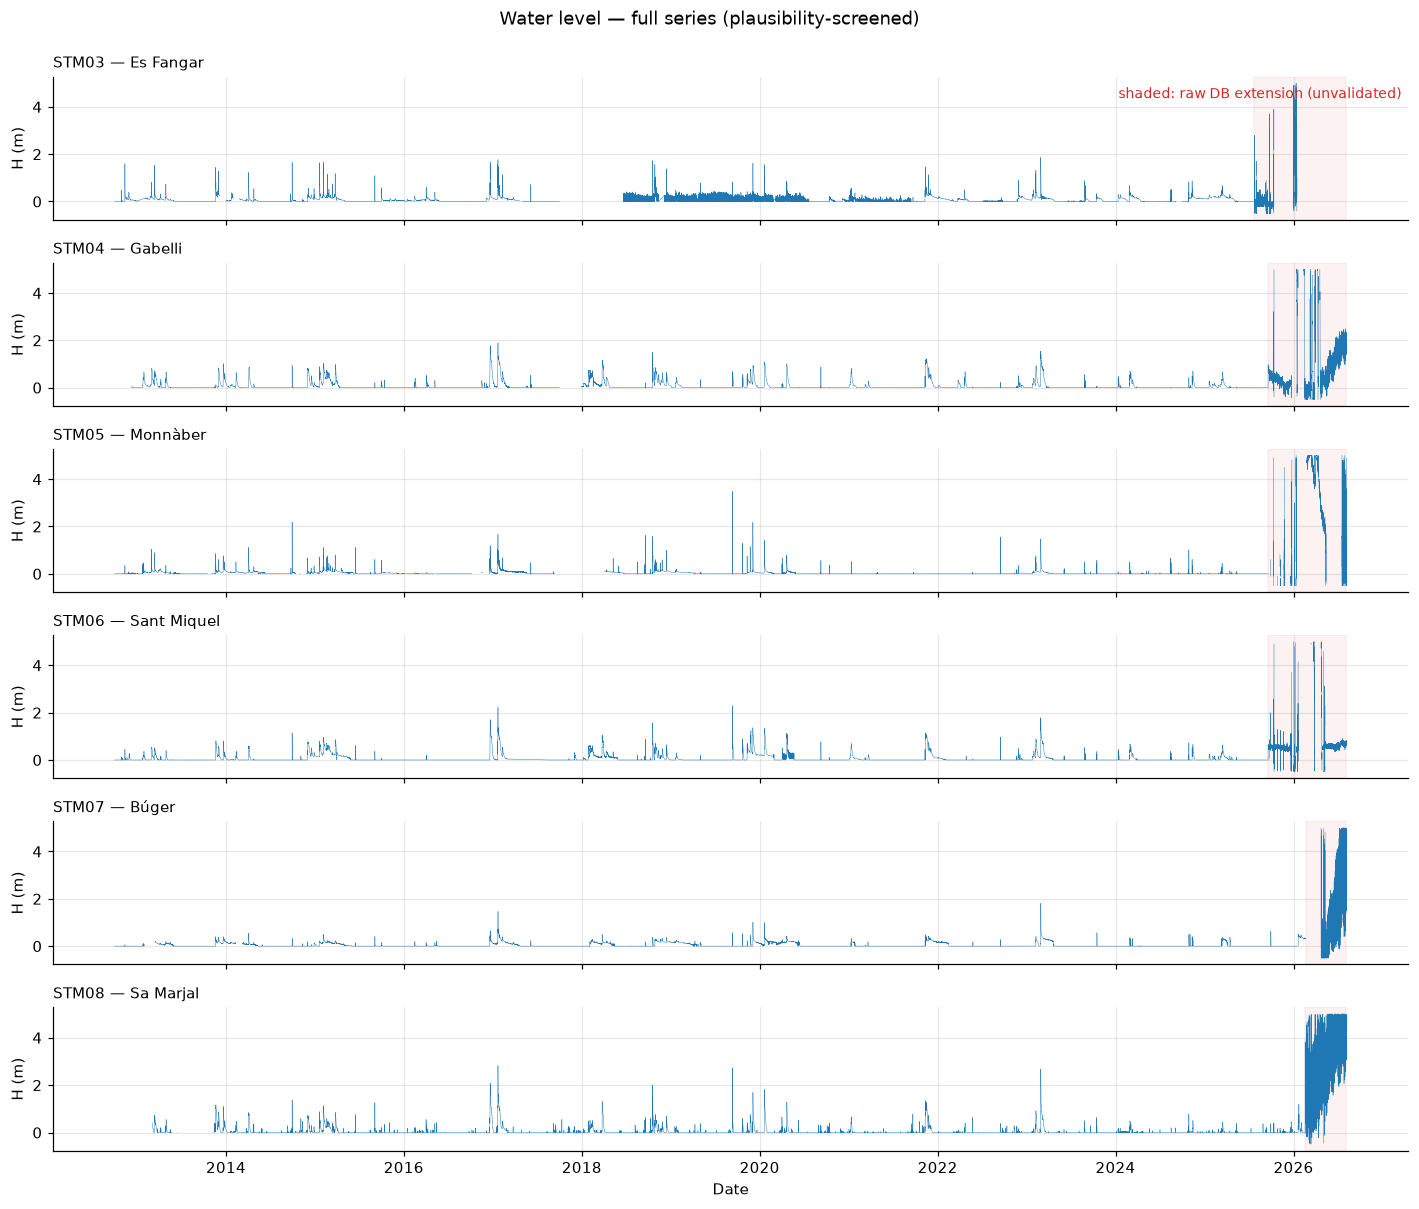

In [11]:
# --- Hydro stations: full water-level series (screened, see §3.1) -------------------
fig, axes = plt.subplots(len(HYDRO), 1, figsize=(13, 11), sharex=True)
for ax, c in zip(axes, HYDRO):
    ax.plot(HC[c].index, HC[c], lw=0.3, color="tab:blue")
    ax.axvspan(pd.Timestamp(EXT_START[c]), HC[c].index.max(), color="tab:red", alpha=0.06)
    name = inventory.loc[inventory.code == c, "name"].iloc[0]
    ax.set_ylabel("H (m)"); ax.set_title(f"{c} — {name}", loc="left", fontsize=10)
axes[0].text(0.995, 0.85, "shaded: raw DB extension (unvalidated)", transform=axes[0].transAxes,
             ha="right", fontsize=9, color="tab:red")
axes[-1].set_xlabel("Date")
fig.suptitle("Water level — full series (plausibility-screened)", y=0.995)
fig.tight_layout()
savefig(fig, "hydro_height_full.png")
plt.show()

saved results/figures/eda/meteo_precip_daily.png


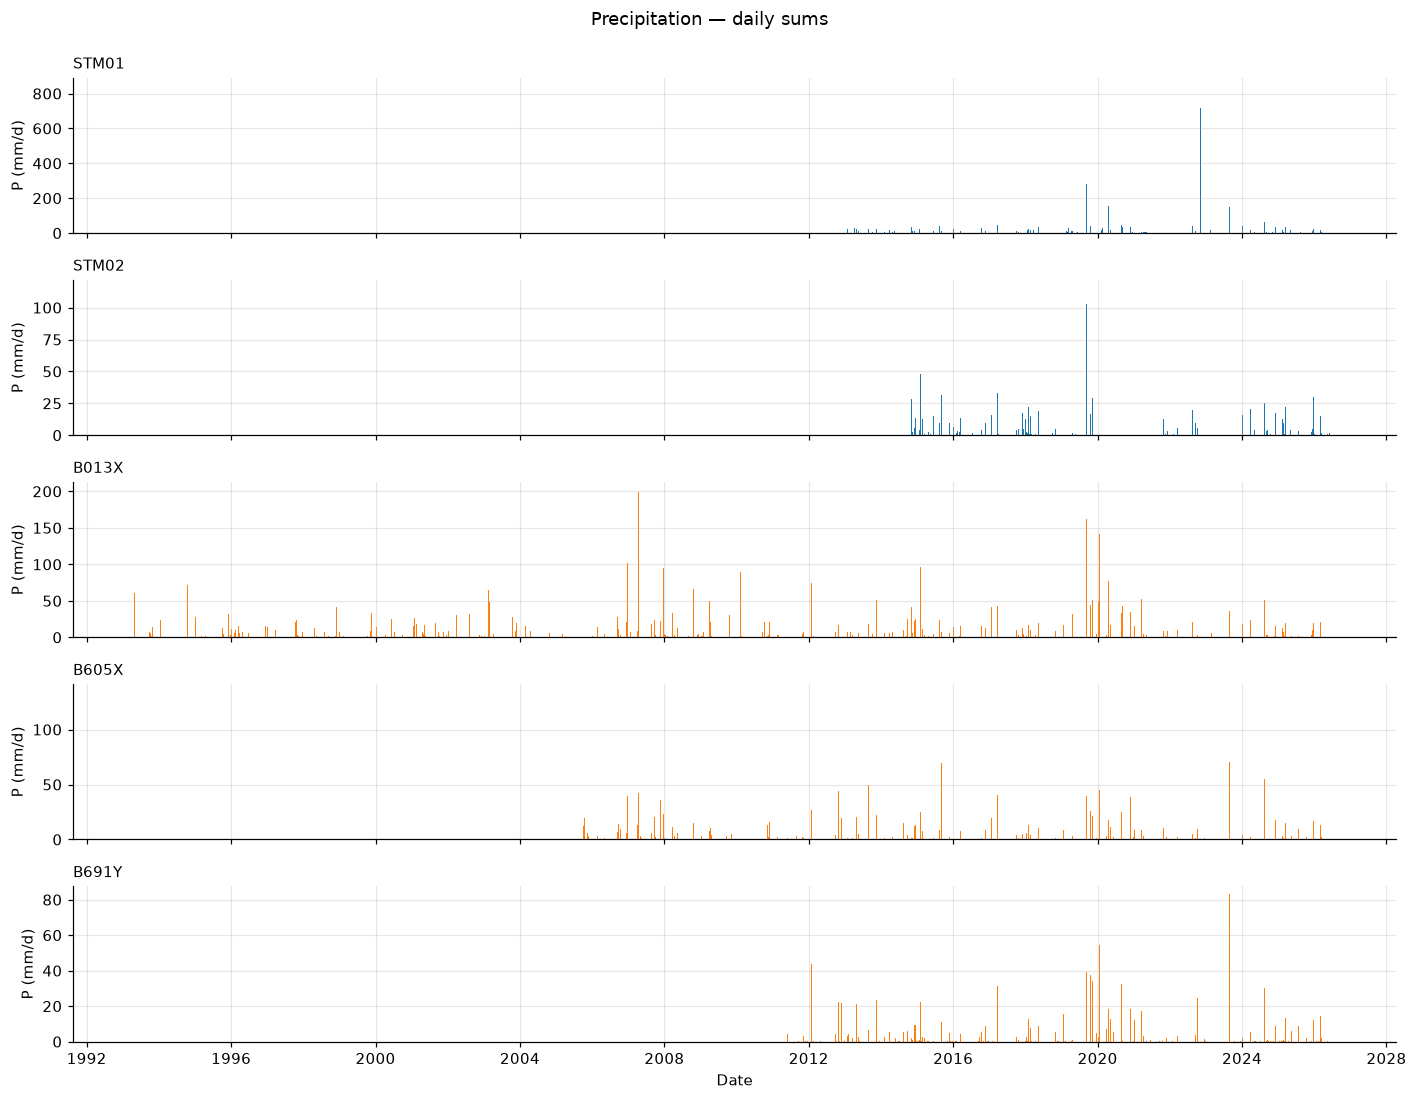

saved results/figures/eda/meteo_temp_full.png


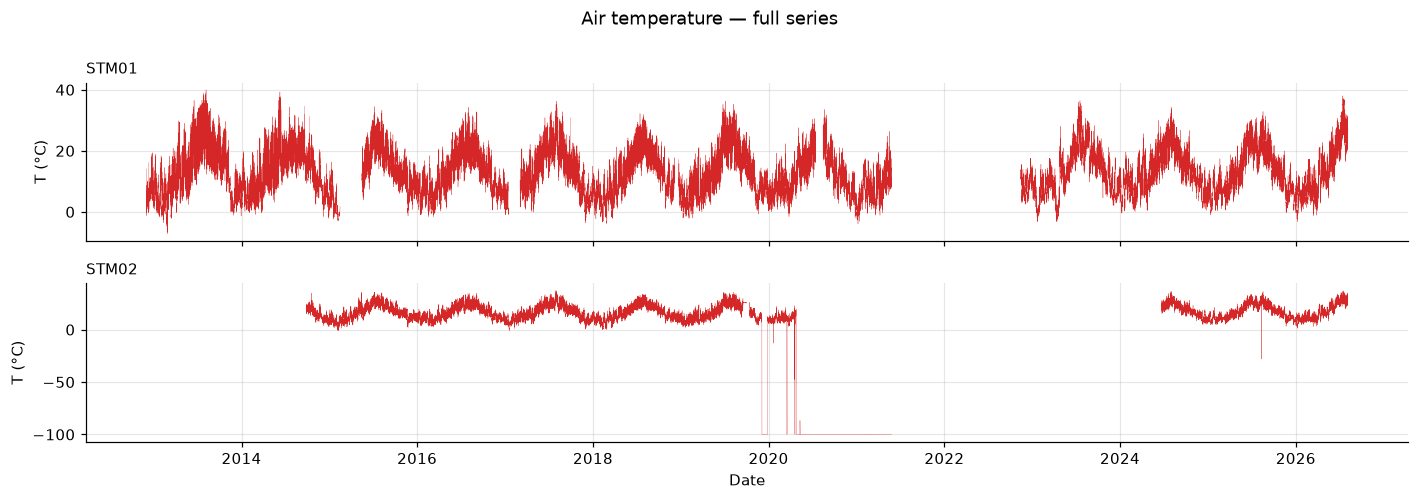

In [12]:
# --- Meteo stations: precipitation (daily sums) and temperature ------------------
fig, axes = plt.subplots(len(METEO + AEMET), 1, figsize=(13, 10), sharex=True)
for ax, c in zip(axes, METEO + AEMET):
    daily = data[c]["PRECIP_mm"].resample("1D").sum(min_count=1)
    ax.bar(daily.index, daily, width=1.0, color="tab:blue" if c in METEO else "tab:orange")
    ax.set_ylabel("P (mm/d)"); ax.set_title(c, loc="left", fontsize=10)
axes[-1].set_xlabel("Date")
fig.suptitle("Precipitation — daily sums", y=0.995)
fig.tight_layout()
savefig(fig, "meteo_precip_daily.png")
plt.show()

fig, axes = plt.subplots(len(METEO), 1, figsize=(13, 4.5), sharex=True)
for ax, c in zip(axes, METEO):
    ax.plot(data[c].index, data[c]["TEMP_C"], lw=0.2, color="tab:red")
    ax.set_ylabel("T (°C)"); ax.set_title(c, loc="left", fontsize=10)
axes[-1].set_xlabel("Date")
fig.suptitle("Air temperature — full series", y=1.0)
fig.tight_layout()
savefig(fig, "meteo_temp_full.png")
plt.show()

saved results/figures/eda/stm08_overview.png


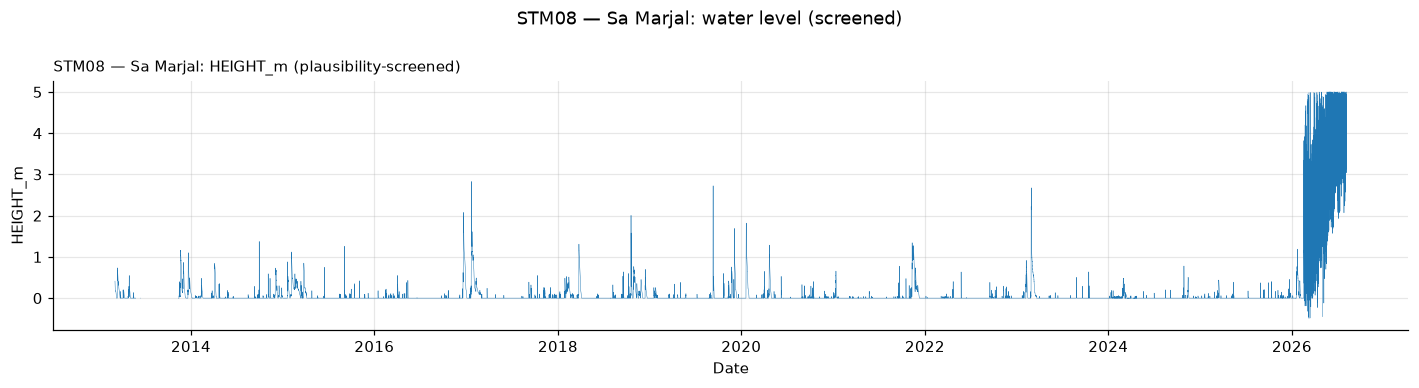

In [13]:
# --- STM08 overview (HEIGHT_m only — other variables will be added from rating curves) ---
stm08 = data[TARGET]
fig, ax = plt.subplots(figsize=(13, 3.5))
s = HC[TARGET] if TARGET in HC else stm08["HEIGHT_m"]
ax.plot(s.index, s, lw=0.3, color="tab:blue")
ax.set_ylabel("HEIGHT_m")
ax.set_xlabel("Date")
ax.set_title("STM08 — Sa Marjal: HEIGHT_m (plausibility-screened)", loc="left", fontsize=10)
fig.suptitle("STM08 — Sa Marjal: water level (screened)", y=0.995)
fig.tight_layout()
savefig(fig, "stm08_overview.png")
plt.show()

## 5. Lagged cross-correlation with STM08

**Goal:** which stations explain the STM08 level best, and with what delay (first estimate of the
basin response / concentration time → feeds the lag features of Phase 2).

Method (exploratory, *not* the final preprocessing):

- Computed on the **validated historical window (2014-09-26 → 2025-07-22)** using the
  plausibility-screened level series (§3.1) — the raw DB-extension data are excluded.
- **Level ↔ level** cross-correlations are computed on an exploratory **10-min grid**
  (`resample('10min').mean()`, NaN where no sample exists; correlations use pairwise-complete
  observations). Lags from −2 h to +72 h.
- **Precip → level** correlations are computed at **1-h resolution** (the native AEMET
  resolution) to avoid any artificial disaggregation of hourly rainfall (see advisor's warning).
  Lags from 0 to +72 h.
- Convention: *lead* ℓ > 0 means the predictor precedes STM08 by ℓ, i.e. r(ℓ) = corr(x(t), y(t+ℓ)).

10-min grid: 569,089 steps | valid share per station:
         STM03  STM04  STM05  STM06  STM07  STM08
valid_%   66.4   71.3   64.0   71.7   75.0   75.9


saved results/figures/eda/ccf_hydro_vs_stm08.png


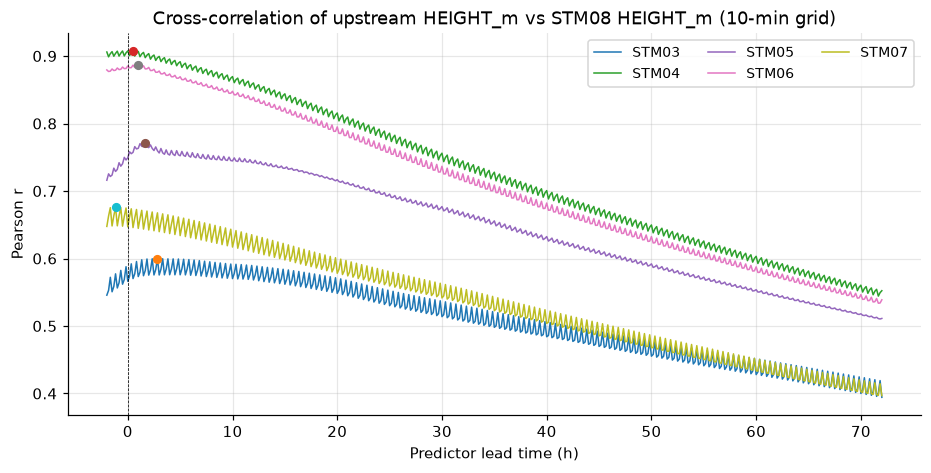

,best_lead_h,r_max,r_lag0
STM03,2.833333,0.600,0.566
STM04,0.500000,0.908,0.908
STM05,1.666667,0.771,0.749
STM06,1.000000,0.887,0.885
STM07,-1.166667,0.676,0.647


In [14]:
# --- Exploratory 10-min level grid ------------------------------------------------
grid10 = pd.date_range(T0, T1_HIST, freq="10min")
lev10 = pd.DataFrame({
    c: HC[c].loc[T0:T1_HIST].resample("10min").mean() for c in HYDRO
}).reindex(grid10)
print(f"10-min grid: {len(lev10):,} steps | valid share per station:")
print((lev10.notna().mean() * 100).round(1).to_frame("valid_%").T)

def lead_corr(x, y, k):
    """corr(x(t), y(t+k)) — k > 0: x leads y by k steps. Pairwise-complete."""
    return x.corr(y.shift(-k))

lags10 = np.arange(-12, 433)  # 10-min steps: -2 h … +72 h
y = lev10[TARGET]
ccf_hydro = pd.DataFrame(
    {c: [lead_corr(lev10[c], y, k) for k in lags10] for c in HYDRO if c != TARGET},
    index=lags10 / 6.0,  # hours
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for c in ccf_hydro.columns:
    ax.plot(ccf_hydro.index, ccf_hydro[c], label=c, lw=1.0)
    best = ccf_hydro[c].idxmax()
    ax.plot(best, ccf_hydro.loc[best, c], "o", ms=5)
ax.axvline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("Predictor lead time (h)"); ax.set_ylabel("Pearson r")
ax.set_title("Cross-correlation of upstream HEIGHT_m vs STM08 HEIGHT_m (10-min grid)")
ax.legend(ncol=3, fontsize=9)
savefig(fig, "ccf_hydro_vs_stm08.png")
plt.show()

best_lags = pd.DataFrame({
    "best_lead_h": ccf_hydro.idxmax(),
    "r_max": ccf_hydro.max().round(3),
    "r_lag0": ccf_hydro.loc[0.0].round(3),
})
best_lags

saved results/figures/eda/ccf_precip_vs_stm08.png


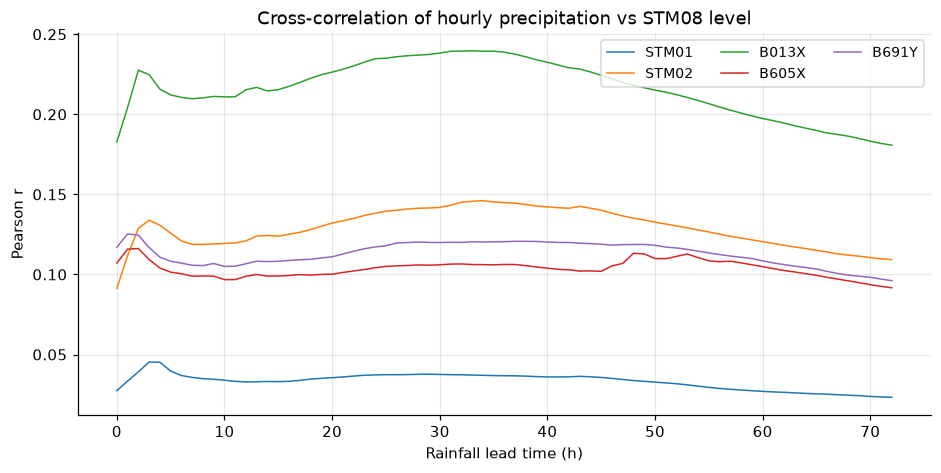

,best_lead_h,r_max
STM01,3,0.045
STM02,34,0.146
B013X,33,0.240
B605X,2,0.116
B691Y,1,0.125


In [15]:
# --- Precipitation → STM08 level (hourly) -----------------------------------------
prec1h = pd.DataFrame({
    c: data[c]["PRECIP_mm"].loc[T0:T1_HIST].resample("1h").sum(min_count=1) for c in METEO + AEMET
}).reindex(pd.date_range(T0, T1_HIST, freq="1h"))
h1h = lev10[TARGET].resample("1h").mean()

lags_h = np.arange(0, 73)
ccf_prec = pd.DataFrame(
    {c: [lead_corr(prec1h[c], h1h, k) for k in lags_h] for c in prec1h.columns},
    index=lags_h,
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for c in ccf_prec.columns:
    ax.plot(ccf_prec.index, ccf_prec[c], label=c, lw=1.0)
ax.set_xlabel("Rainfall lead time (h)"); ax.set_ylabel("Pearson r")
ax.set_title("Cross-correlation of hourly precipitation vs STM08 level")
ax.legend(ncol=3, fontsize=9)
savefig(fig, "ccf_precip_vs_stm08.png")
plt.show()

pd.DataFrame({"best_lead_h": ccf_prec.idxmax(), "r_max": ccf_prec.max().round(3)})

**Interpretation (screened series, validated window).**

- **Level ↔ level.** Upstream stations correlate strongly with STM08: **STM04 r = 0.91 at 0.5 h
  lead**, **STM06 r = 0.89 at 1 h**, **STM05 r = 0.77 at 1.7 h**, **STM03 r = 0.60 at 2.8 h**.
  These short leads are a first estimate of the flood-wave travel/response times and directly
  support the lag features proposed in the plan (t−1h … t−24h) and the t+1h/6h/24h forecast
  horizons. **STM07 (Búger) behaves differently** (r = 0.68 with STM08 slightly *leading*):
  consistent with a slower or hydraulically independent sub-catchment arm — to be confirmed with
  the basin topology (open question in the plan).
- **Rainfall → level.** Instantaneous hourly rainfall correlates only weakly (r ≤ 0.24, leads
  1–34 h): with ~90 % dry intervals and a buffering wetland, the linear rainfall–level link
  emerges only at **event scale** or through **antecedent accumulations** — exactly the features
  planned for Phase 2 (3–48 h cumulative precipitation, API).
- **Caveat:** correlations use pairwise-complete observations on a grid with mixed native
  frequencies; the fine high-frequency ripple visible on the curves is a resampling artifact of
  binning 15-min samples onto a 10-min grid (the number of paired points oscillates with lag) —
  the definitive 10-min grid in Phase 2 will treat this explicitly. All values are preliminary.

## 6. Flood-event identification (preliminary, literature-based rule)

There is no unique universal definition of a hydrological *event*. The rule applied here combines
standard, reproducible criteria from the literature:

- **Rainfall events — Inter-Event Time Definition (IETD).** Two rain pulses belong to independent
  events when separated by a dry period ≥ IETD (Restrepo-Posada & Eagleson, 1982; Dunkerley, 2008).
  Instead of fixing the IETD arbitrarily, it is selected by a sensitivity analysis (6/12/24/48 h)
  using the independence criterion CV(inter-event dry time) ≈ 1 expected under a Poisson process.
- **Runoff/level events — automated separation.** Automated hydrograph event separation usually
  combines baseflow separation, rise detection and merging of multi-peak events
  (Tarasova et al., 2018). Here, adapted to a **wetland level** (no true zero flow): a rolling
  low-quantile baseline, rise detection over a 3-h window with a robust (MAD-based) threshold,
  merging of rises closer than a minimum inter-event time (MIT), and minimum
  amplitude/duration filters.
- **Event-scale characterization** follows the Mediterranean ephemeral-stream literature
  (Serrano-Notivoli et al., 2022): duration, magnitude, max intensity, response ΔH.

> **⚠ Effect of missing data (explicit caveat).** The detection runs on the **validated
> historical window (2014-09-26 → 2025-07-22)** — the raw DB extension is excluded (§3.1). Gaps in
> STM08 `HEIGHT_m` can still (a) *split* one real event into two detected pieces, (b) *hide* an
> event completely, or (c) make the event end undeterminable. Every event overlapping a gap > 3 h
> is flagged (`gap_flag`), and events whose boundaries are uncertain are marked. Counts below are
> therefore a **lower bound** on the true number of events and must be revisited after Phase-2
> gap treatment.

**References**
- Restrepo-Posada, P. & Eagleson, P. (1982). *Identification of independent rainstorms*. J. Hydrol. 55.
- Dunkerley, D. (2008). *Identifying individual rain events from pluviograph records*. Hydrol. Process. 22.
- Tarasova, L. et al. (2018). *Exploring controls on rainfall-runoff events: 1. Time series-based event separation*. WRR 54.
- Serrano-Notivoli, R. et al. (2022). *Rainfall–runoff relationships at event scale in western Mediterranean ephemeral streams*. HESS 26.
- Coles, S. (2001). *An Introduction to Statistical Modeling of Extreme Values* (POT).

In [16]:
# --- 6.1 Rainfall events: IETD extraction + sensitivity ---------------------------
def extract_rain_events(p, ietd, wet_thr=0.2):
    """Group wet pulses (P >= wet_thr) separated by gaps > ietd into events."""
    w = p.dropna()
    wt = w.index[w >= wet_thr]
    if len(wt) < 2:
        return pd.DataFrame(columns=["start", "end", "depth_mm", "duration_h", "max_1h_mm"])
    ev_id = (wt.to_series().diff() > ietd).fillna(True).cumsum()
    rows = []
    for _, grp in wt.to_series().groupby(ev_id):
        s, e = grp.index[0], grp.index[-1]
        seg = w.loc[s:e]
        rows.append({
            "start": s, "end": e,
            "depth_mm": seg.sum(),
            "duration_h": (e - s).total_seconds() / 3600,
            "max_1h_mm": seg.resample("1h").sum(min_count=1).max(),
        })
    return pd.DataFrame(rows)

ietd_options = [6, 12, 24, 48]  # hours
sens_rows = []
rain_events_all = {c: {} for c in METEO + AEMET}
for c in METEO + AEMET:
    p = data[c]["PRECIP_mm"].loc[T0:T1_HIST]
    for ietd_h in ietd_options:
        ev = extract_rain_events(p, pd.Timedelta(hours=ietd_h))
        rain_events_all[c][ietd_h] = ev
        dry = (ev["start"].iloc[1:].to_numpy() - ev["end"].iloc[:-1].to_numpy())
        dry_h = pd.Series(dry) / pd.Timedelta(hours=1)
        cv = dry_h.std() / dry_h.mean() if len(dry_h) else np.nan
        sens_rows.append({"station": c, "IETD_h": ietd_h,
                          "n_events": len(ev), "CV_dry": round(cv, 3)})

sens_ietd = pd.DataFrame(sens_rows).pivot_table(
    index="station", columns="IETD_h", values=["n_events", "CV_dry"])
print("IETD sensitivity (CV(inter-event dry time) ≈ 1 → independent events):")
print(sens_ietd.to_string())

# Select the IETD whose CV is closest to 1 for the reference station STM01
_ref = pd.DataFrame(sens_rows).query("station == 'STM01'").set_index("IETD_h")
IETD_H = int((_ref["CV_dry"] - 1).abs().idxmin())
print(f"\nSelected IETD = {IETD_H} h (CV closest to 1 at STM01; used for rain-event pairing)")
rain_events = {c: rain_events_all[c][IETD_H] for c in METEO + AEMET}

IETD sensitivity (CV(inter-event dry time) ≈ 1 → independent events):
        CV_dry                      n_events                     
IETD_h      6      12     24     48       6      12     24     48
station                                                          
B013X    1.941  1.726  1.513  1.303    780.0  632.0  493.0  365.0
B605X    2.170  1.910  1.663  1.474    845.0  663.0  503.0  385.0
B691Y    2.383  2.113  1.855  1.629    953.0  748.0  563.0  408.0
STM01    3.193  2.932  2.403  2.033   1120.0  925.0  553.0  350.0
STM02    4.089  3.662  3.219  2.874    886.0  695.0  508.0  369.0

Selected IETD = 48 h (CV closest to 1 at STM01; used for rain-event pairing)


In [17]:
# --- 6.2 Level-event detection at STM08 --------------------------------------------
def _prep_level(h, rise_win=18, gap_h=3.0):
    """Precompute baseline, 3-h rise and long-NaN runs (shared across parameter sweeps)."""
    idx = h.index
    base = h.rolling("7D", min_periods=72).quantile(0.2)
    dh = h - h.shift(rise_win)  # 3-h trailing rise on the 10-min grid
    isn = h.isna().to_numpy()
    edges = np.diff(isn.astype(np.int8))
    g_starts = list(np.where(edges == 1)[0] + 1)
    g_ends = list(np.where(edges == -1)[0] + 1)
    if isn[0]: g_starts = [0] + g_starts
    if isn[-1]: g_ends = g_ends + [len(isn)]
    long_gaps = [(a, b) for a, b in zip(g_starts, g_ends)
                 if (idx[min(b, len(idx) - 1)] - idx[max(a - 1, 0)]) > pd.Timedelta(hours=gap_h)]
    return {"base": base, "dh": dh, "isn": isn, "long_gaps": long_gaps}

def identify_level_events(h, mit_h=24, k_mad=3.0, min_dh=0.10, min_dur_h=2.0,
                          end_frac=0.15, max_rec_days=7, prep=None):
    """Literature-based, gap-aware level-event detection.

    Steps: rolling 7-day Q20 baseline → rise detection (ΔH over 3 h > robust threshold)
    → merge rises closer than MIT → start/end at local minimum / return to baseline
    → filters: min amplitude, min duration. Events touching data gaps are flagged.
    Returns (events_df, info_dict).
    """
    if prep is None:
        prep = _prep_level(h)
    base, dh, long_gaps = prep["base"], prep["dh"], prep["long_gaps"]
    idx = h.index
    mad = (dh - dh.median()).abs().median()
    thr = max(0.03, k_mad * 1.4826 * mad)
    cand = (dh > thr).fillna(False).to_numpy()

    def gap_between(i, j):
        return any(a < j and b > i for a, b in long_gaps)

    # group candidates with merging gap < MIT
    ci = np.where(cand)[0]
    groups, cur = [], []
    mit_steps = int(mit_h * 6)
    for i in ci:
        if cur and i - cur[-1] > mit_steps:
            groups.append(cur); cur = []
        cur.append(i)
    if cur: groups.append(cur)

    events, discarded = [], 0
    for g in groups:
        i0, i1 = g[0], g[-1]
        flags = []
        # start: local minimum within 6 h before the first rise
        w0 = max(i0 - 36, 0)
        seg = h.iloc[w0:i0 + 1]
        start_i = seg.idxmin() if seg.notna().any() else idx[max(i0 - rise_win, 0)]
        if not seg.notna().any(): flags.append("start_uncertain")
        start_i = idx.get_loc(start_i) if not isinstance(start_i, int) else start_i
        # peak: max within [first rise, last rise + 24 h]
        w1 = min(i1 + 144, len(h) - 1)
        seg = h.iloc[i0:w1 + 1]
        if not seg.notna().any():
            discarded += 1; continue
        peak_i = idx.get_loc(seg.idxmax())
        # base level at start
        b0 = base.iloc[start_i]
        if np.isnan(b0): b0 = h.iloc[start_i]
        if np.isnan(b0):
            discarded += 1; continue
        peak_level = h.iloc[peak_i]
        delta_h = peak_level - b0
        # end: return to base + end_frac*amplitude, within max_rec_days
        end_i = None
        j = peak_i
        jmax = min(peak_i + max_rec_days * 144, len(h) - 1)
        while j <= jmax:
            v = h.iloc[j]
            if np.isnan(v):
                j += 1; continue
            if v <= b0 + end_frac * delta_h:
                end_i = j; break
            j += 1
        if end_i is None:
            end_i = jmax; flags.append("recession_cap")
        duration_h = (idx[end_i] - idx[start_i]).total_seconds() / 3600
        if delta_h < min_dh or duration_h < min_dur_h:
            discarded += 1; continue
        if gap_between(start_i, end_i): flags.append("gap_inside")
        events.append({
            "start": idx[start_i], "end": idx[end_i], "peak_time": idx[peak_i],
            "base_level_m": round(float(b0), 3), "peak_level_m": round(float(peak_level), 3),
            "delta_H_m": round(float(delta_h), 3), "duration_h": round(duration_h, 1),
            "rise_thr_used": round(float(thr), 4),
            "gap_flag": "gap_inside" in flags,
            "flags": ",".join(flags) if flags else "",
        })
    info = {"rise_threshold_m": float(thr), "n_groups": len(groups),
            "discarded": discarded, "mit_h": mit_h, "k_mad": k_mad}
    return pd.DataFrame(events), info

h_stm08 = lev10[TARGET]
prep_stm08 = _prep_level(h_stm08)
events, evinfo = identify_level_events(h_stm08, prep=prep_stm08)
print(f"Detected level events: {len(events)} "
      f"(discarded {evinfo['discarded']} sub-threshold groups; "
      f"rise threshold = {evinfo['rise_threshold_m']:.3f} m)")
events.head(10)

Detected level events: 168 (discarded 144 sub-threshold groups; rise threshold = 0.030 m)


,start,end,peak_time,base_level_m,peak_level_m,delta_H_m,duration_h,rise_thr_used,gap_flag,flags
0,2014-09-28 02:30:00,2014-09-29 21:00:00,2014-09-29 15:30:00,0.00,1.375,1.375,42.5,0.03,False,
1,2014-11-04 01:40:00,2014-11-04 18:00:00,2014-11-04 10:10:00,0.00,0.590,0.590,16.3,0.03,False,
2,2014-11-11 11:10:00,2014-11-12 02:00:00,2014-11-11 20:10:00,0.00,0.480,0.480,14.8,0.03,False,
3,2014-11-25 21:00:00,2014-11-28 13:00:00,2014-11-26 06:40:00,0.00,0.100,0.100,64.0,0.03,False,
4,2014-12-02 01:10:00,2014-12-09 22:40:00,2014-12-02 22:40:00,0.00,0.730,0.730,189.5,0.03,False,recession_cap
5,2014-12-17 02:30:00,2014-12-19 22:10:00,2014-12-17 13:40:00,0.00,0.300,0.300,67.7,0.03,False,
6,2014-12-28 04:00:00,2014-12-30 16:00:00,2014-12-28 12:10:00,0.00,0.250,0.250,60.0,0.03,False,
7,2015-01-19 17:30:00,2015-01-26 14:40:00,2015-01-20 17:40:00,0.00,0.880,0.880,165.2,0.03,False,
8,2015-02-04 09:00:00,2015-02-12 12:30:00,2015-02-05 12:30:00,0.00,1.120,1.120,195.5,0.03,False,recession_cap
9,2015-02-17 13:10:00,2015-02-20 17:10:00,2015-02-18 13:00:00,0.21,0.590,0.380,76.0,0.03,False,


In [18]:
# --- 6.3 Event enrichment: rainfall, antecedent wetness, upstream response ---------
daily_p = prec1h[METEO + AEMET].resample("1D").sum(min_count=1).mean(axis=1)
api7 = daily_p.rolling(7, min_periods=5).sum().shift(1)

def season_of(ts):
    return {12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
            6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"}[ts.month]

enr = []
for _, ev in events.iterrows():
    a, b = ev.start - pd.Timedelta(hours=24), ev.end
    row = {}
    win_h = (b - a).total_seconds() / 3600
    for c in METEO + AEMET:
        seg = prec1h.loc[a:b, c]
        cov = seg.notna().mean()
        row[f"P_{c}_mm"] = round(seg.sum(), 1) if cov >= 0.8 else np.nan
    row["max_1h_int_mm"] = prec1h.loc[a:b, METEO + AEMET].max().max()
    row["API7_mm"] = round(float(api7.asof(ev.start)), 1) if not np.isnan(api7.asof(ev.start)) else np.nan
    # upstream response: height range within window (works also in the HEIGHT-only period)
    ups = 0
    for c in HYDRO[:-1]:
        seg = lev10.loc[ev.start - pd.Timedelta(hours=12):ev.end, c].dropna()
        if len(seg) and (seg.max() - seg.min()) > 0.05:
            ups += 1
    row["n_upstream_responding"] = ups
    # rain driver: any rainfall event overlapping [start-24h, start+6h]
    w0, w1 = ev.start - pd.Timedelta(hours=24), ev.start + pd.Timedelta(hours=6)
    row["has_rain_driver"] = any(
        ((evr.start <= w1) & (evr.end >= w0)).any() for evr in rain_events.values())
    row["season"] = season_of(ev.start)
    enr.append(row)

events = pd.concat([events.reset_index(drop=True), pd.DataFrame(enr)], axis=1)
events.insert(0, "event_id", [f"E{i:03d}" for i in range(1, len(events) + 1)])
events["hydro_year"] = events.start.dt.year + (events.start.dt.month >= 10)

out_csv = PROCESSED / "events_stm08.csv"
events.to_csv(out_csv, index=False)
print(f"saved {out_csv.relative_to(ROOT)}  ({len(events)} events)")
events

saved data/processed/events_stm08.csv  (168 events)


,event_id,start,end,peak_time,base_level_m,peak_level_m,delta_H_m,duration_h,rise_thr_used,gap_flag,...,P_STM02_mm,P_B013X_mm,P_B605X_mm,P_B691Y_mm,max_1h_int_mm,API7_mm,n_upstream_responding,has_rain_driver,season,hydro_year
0,E001,2014-09-28 02:30:00,2014-09-29 21:00:00,2014-09-29 15:30:00,0.0,1.375,1.375,42.5,0.03,False,...,63.4,50.0,11.6,19.8,40.2,NaN,5,True,SON,2014
1,E002,2014-11-04 01:40:00,2014-11-04 18:00:00,2014-11-04 10:10:00,0.0,0.590,0.590,16.3,0.03,False,...,35.2,NaN,31.4,31.4,17.2,2.0,1,True,SON,2015
2,E003,2014-11-11 11:10:00,2014-11-12 02:00:00,2014-11-11 20:10:00,0.0,0.480,0.480,14.8,0.03,False,...,27.6,NaN,23.6,31.0,11.8,59.1,2,True,SON,2015
3,E004,2014-11-25 21:00:00,2014-11-28 13:00:00,2014-11-26 06:40:00,0.0,0.100,0.100,64.0,0.03,False,...,12.6,4.0,7.6,9.0,8.8,0.2,0,True,SON,2015
4,E005,2014-12-02 01:10:00,2014-12-09 22:40:00,2014-12-02 22:40:00,0.0,0.730,0.730,189.5,0.03,False,...,154.8,223.3,63.8,35.8,17.2,65.3,5,True,DJF,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,E164,2025-03-09 06:00:00,2025-03-10 20:20:00,2025-03-10 14:30:00,0.0,0.189,0.189,38.3,0.03,False,...,23.0,42.4,11.8,14.6,13.0,31.7,5,True,MAM,2025
164,E165,2025-03-13 09:30:00,2025-03-18 23:20:00,2025-03-15 16:00:00,0.0,0.439,0.439,133.8,0.03,False,...,75.2,63.0,31.0,30.0,17.8,48.4,5,True,MAM,2025
165,E166,2025-05-08 22:00:00,2025-05-09 18:30:00,2025-05-09 15:10:00,0.0,0.103,0.103,20.5,0.03,False,...,14.0,0.0,11.4,24.8,15.4,15.3,0,True,MAM,2025
166,E167,2025-05-11 09:20:00,2025-05-12 15:30:00,2025-05-12 12:30:00,0.0,0.388,0.388,30.2,0.03,False,...,16.8,0.0,13.4,25.4,20.8,28.9,2,True,MAM,2025


Events with data gaps inside : 0 (0%)  ← treat with caution
Events without rain driver   : 9 (possible hidden rain in gaps, or groundwater/tide influence)
Median ΔH / duration         : 0.26 m / 26.4 h


saved results/figures/eda/events_summary.png


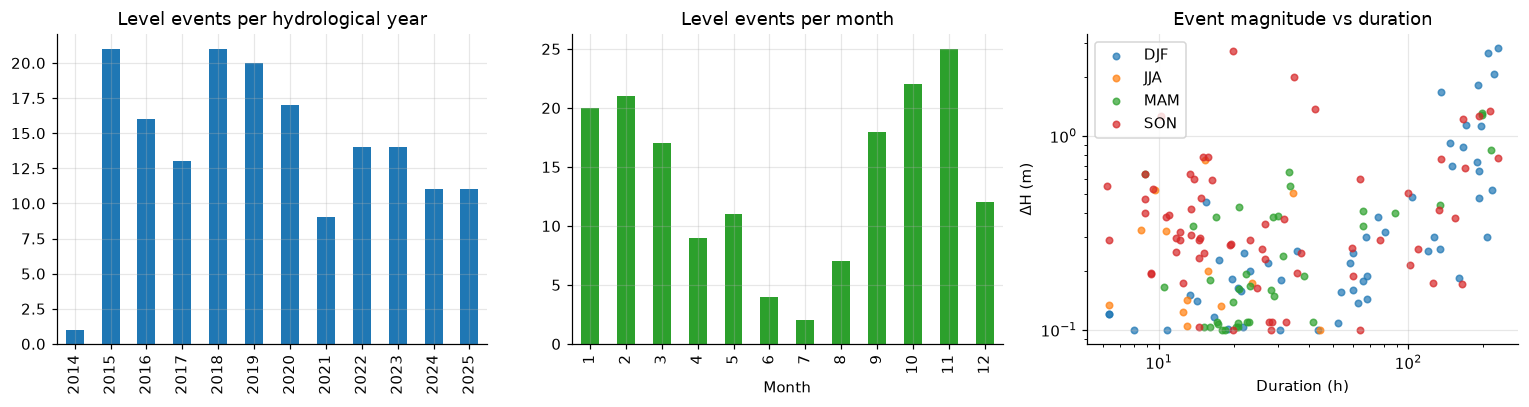

In [19]:
# --- 6.4 Characterization -----------------------------------------------------------
print(f"Events with data gaps inside : {events.gap_flag.sum()} "
      f"({100 * events.gap_flag.mean():.0f}%)  ← treat with caution")
print(f"Events without rain driver   : {(~events.has_rain_driver).sum()} "
      f"(possible hidden rain in gaps, or groundwater/tide influence)")
print(f"Median ΔH / duration         : {events.delta_H_m.median():.2f} m / "
      f"{events.duration_h.median():.1f} h")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
events.groupby("hydro_year").size().plot.bar(ax=axes[0], color="tab:blue")
axes[0].set_title("Level events per hydrological year"); axes[0].set_xlabel("")
events.start.dt.month.value_counts().sort_index().plot.bar(ax=axes[1], color="tab:green")
axes[1].set_title("Level events per month"); axes[1].set_xlabel("Month")
for s, grp in events.groupby("season"):
    axes[2].scatter(grp.duration_h, grp.delta_H_m, label=s, s=18, alpha=0.7)
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("Duration (h)"); axes[2].set_ylabel("ΔH (m)")
axes[2].set_title("Event magnitude vs duration"); axes[2].legend()
fig.tight_layout()
savefig(fig, "events_summary.png")
plt.show()

saved results/figures/eda/events_top5.png


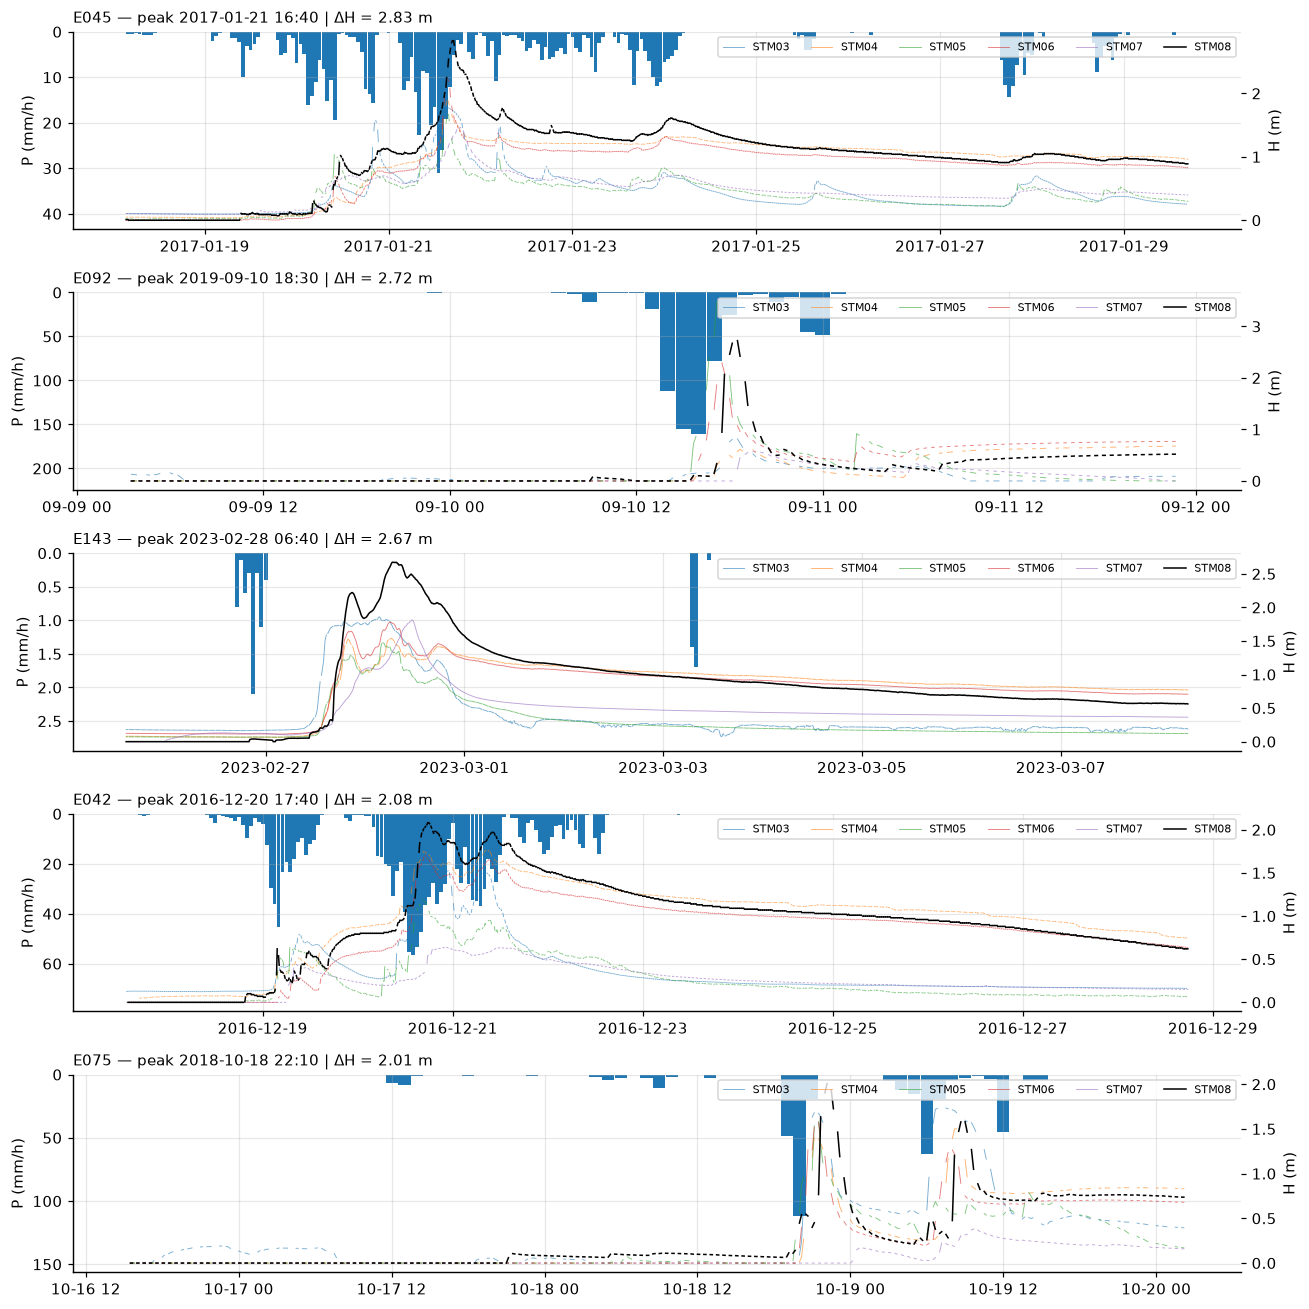

MIT_h,12,24,48
k_mad,,,
2.0,207.0,168.0,143.0
3.0,207.0,168.0,143.0
4.0,207.0,168.0,143.0


In [20]:
# --- 6.5 Top-5 events + parameter sensitivity ---------------------------------------
top5 = events.nlargest(5, "delta_H_m")
fig, axes = plt.subplots(len(top5), 1, figsize=(12, 12), sharex=False)
for ax, (_, ev) in zip(axes, top5.iterrows()):
    w0, w1 = ev.start - pd.Timedelta(hours=24), ev.end + pd.Timedelta(hours=24)
    pwin = prec1h.loc[w0:w1, METEO + AEMET].sum(axis=1, min_count=1)
    ax.bar(pwin.index, pwin, width=0.04, color="tab:blue")
    ax.set_ylim(bottom=pwin.max() * 1.4 if pwin.notna().any() else 1, top=0)  # inverted hyetograph
    ax.set_ylabel("P (mm/h)")
    ax2 = ax.twinx()
    for c in HYDRO:
        ax2.plot(lev10.loc[w0:w1].index, lev10.loc[w0:w1, c],
                 lw=1.0 if c == TARGET else 0.6,
                 color="k" if c == TARGET else None, alpha=1.0 if c == TARGET else 0.6,
                 label=c)
    ax2.set_ylabel("H (m)")
    gap_txt = " [GAP]" if ev.gap_flag else ""
    ax.set_title(f"{ev.event_id} — peak {ev.peak_time:%Y-%m-%d %H:%M} | "
                 f"ΔH = {ev.delta_H_m:.2f} m{gap_txt}", loc="left", fontsize=10)
    ax2.legend(ncol=6, fontsize=7, loc="upper right")
    ax2.grid(False)
fig.tight_layout()
savefig(fig, "events_top5.png")
plt.show()

# Sensitivity of the event count to the two main parameters
sens = []
for k in (2.0, 3.0, 4.0):
    for mit in (12, 24, 48):
        ev_s, _ = identify_level_events(h_stm08, mit_h=mit, k_mad=k, prep=prep_stm08)
        sens.append({"k_mad": k, "MIT_h": mit, "n_events": len(ev_s)})
pd.DataFrame(sens).pivot_table(index="k_mad", columns="MIT_h", values="n_events")

## 7. Seasonality (Mediterranean regime)

Monthly climatologies of precipitation and of the STM08 level, plus the monthly distribution of
the identified level events. The hydrological year is taken October–September, as customary in
Mediterranean hydrology.

saved results/figures/eda/seasonality.png


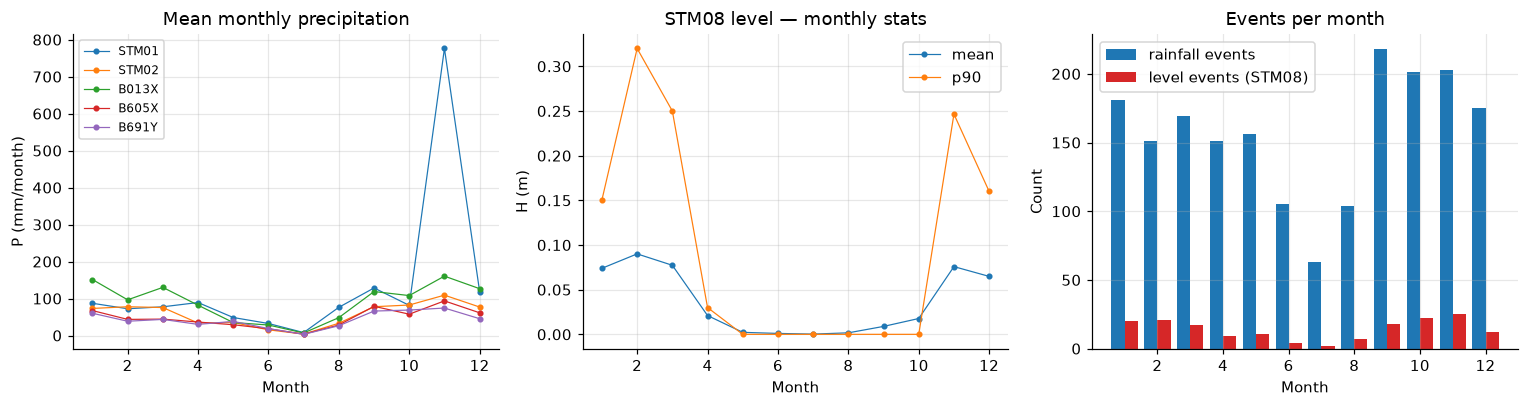

In [21]:
# --- Monthly climatologies ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (a) mean monthly precipitation totals
for c in METEO + AEMET:
    d = data[c]["PRECIP_mm"].loc[T0:T1_HIST].resample("1D").sum(min_count=1)
    mt = d.resample("1ME").agg(["sum", "count"])
    mt.loc[mt["count"] < 25, "sum"] = np.nan  # discard largely incomplete months
    clim = mt["sum"].groupby(mt.index.month).mean()
    axes[0].plot(clim.index, clim.values, marker="o", ms=3, label=c)
axes[0].set_xlabel("Month"); axes[0].set_ylabel("P (mm/month)")
axes[0].set_title("Mean monthly precipitation"); axes[0].legend(fontsize=8)

# (b) STM08 level monthly stats
h = lev10[TARGET]
grp = h.groupby(h.index.month)
axes[1].plot(grp.mean().index, grp.mean().values, marker="o", ms=3, label="mean")
axes[1].plot(grp.quantile(0.9).index, grp.quantile(0.9).values, marker="o", ms=3, label="p90")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("H (m)")
axes[1].set_title("STM08 level — monthly stats"); axes[1].legend()

# (c) events per month vs rain events per month
m_lev = events.start.dt.month.value_counts().sort_index()
m_rain = pd.concat([evr.start.dt.month for evr in rain_events.values()]).value_counts().sort_index()
axes[2].bar(m_rain.index - 0.2, m_rain.values, width=0.4, label="rainfall events", color="tab:blue")
axes[2].bar(m_lev.index + 0.2, m_lev.values, width=0.4, label="level events (STM08)", color="tab:red")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("Count")
axes[2].set_title("Events per month"); axes[2].legend()

fig.tight_layout()
savefig(fig, "seasonality.png")
plt.show()

## 8. Summary & implications for Phase 2

**Inventory & integrity**
- 11 stations loaded (6 hydro, 2 STM meteo, 3 AEMET); full common window **2014-09-26 → 2026-07-02** (~12 years); **validated analysis window 2014-09-26 → 2025-07-22**.
- Duplicated timestamps in most STM stations (up to ~1.7 k in STM03) and 4 empty-timestamp rows in STM03 — dropped at load; cause to be confirmed in Phase 2.
- **73 raw Excel tipping-bucket formulas** (`=0.2*N`, `=N*0.2`) recovered in STM02 `PRECIP_mm` → fix `clean_STM02.py` upstream.

**Missing data & quality (decisive findings)**
- Largest null rates: `LOAD_kg` (STM03 43 %, STM05 25 %), `STM02 TEMP_C` (29 %), `STM03 DISCHARGE_m3s`/`VOLUME_m3` (22 %). `HEIGHT_m` is the most complete variable everywhere → confirms it as the right target.
- STM08 has 31 NaN runs in `HEIGHT_m`, 4 of them longer than 7 days.
- **The DB-extension period (2025-07-23 / 2026-02-17 →) is raw, unharmonized and unvalidated**: out-of-range spikes (up to 177 m), negative plateaus, and non-physical daily sawtooth oscillations — 100 % of out-of-range values occur in 2025–2026. **All quantitative results in this notebook exclude the extension period.** *Critical action item:* harmonize units/datums and apply the `quality` flags to the extension data before modeling use (advisor requirement); the train/val/test split must account for this.

**Predictors & lags**
- Upstream levels explain STM08 well at short leads: STM04 r = 0.91 @ 0.5 h, STM06 r = 0.89 @ 1 h, STM05 r = 0.77 @ 1.7 h, STM03 r = 0.60 @ 2.8 h; STM07 behaves differently (r = 0.68, STM08 slightly leading → topology to confirm).
- Instantaneous rainfall–level correlation is weak (r ≤ 0.24) → event-scale / accumulated-rainfall features are essential (plan's 3–48 h accumulations, API).

**Events (preliminary, literature-based rule)**
- **168 level events** detected at STM08 in the validated window (median ΔH ≈ 0.26 m, median duration ≈ 26 h; 0 overlapping data gaps; 9 without a detected rainfall driver).
- Events per hydrological year: median 14, min 1, max 21 → usable for ML, but the count is a **lower bound** (gap-hidden events).
- Rainfall IETD sensitivity: CV never reaches 1 (Mediterranean storm clustering); 48 h adopted as closest to independence at STM01.
- Events table saved to `data/processed/events_stm08.csv` (draft of the advisor's *Events table*; rebuild after Phase-2 gap treatment; split train/val/test **by event**, never inside one).

**Seasonality** — see §7: precipitation and events concentrate in autumn–spring; the wetland keeps a permanent level with superimposed flood pulses.

In [22]:
# --- Auto-summary of key numbers -----------------------------------------------------
print("KEY FINDINGS (auto-generated)")
print("=" * 60)
print(f"Full common window     : {T0.date()} → {T1.date()}")
print(f"Validated analysis win.: {T0.date()} → {T1_HIST.date()}")
worst = null_tbl.nlargest(5, "null_%")[["station", "variable", "null_%"]]
print("Largest null rates     :")
for _, r in worst.iterrows():
    print(f"   {r.station:6s} {r.variable:15s} {r['null_%']:6.2f} %")
print(f"STM08 gap runs > 7 days: {(gaps08.span_h > 24 * 7).sum()}")
print("\nBest predictor lags (level → STM08):")
print(best_lags.to_string())
print("\nRainfall → STM08 (hourly):")
print(pd.DataFrame({'best_lead_h': ccf_prec.idxmax(),
                    'r_max': ccf_prec.max().round(3)}).to_string())
print(f"\nLevel events detected  : {len(events)} "
      f"({events.gap_flag.sum()} with gaps inside, "
      f"{(~events.has_rain_driver).sum()} without rain driver)")
print(f"Events per hydro-year  : min {events.groupby('hydro_year').size().min()}, "
      f"max {events.groupby('hydro_year').size().max()}, "
      f"median {events.groupby('hydro_year').size().median():.0f}")

KEY FINDINGS (auto-generated)
Full common window     : 2014-09-26 → 2026-07-02
Validated analysis win.: 2014-09-26 → 2025-07-22
Largest null rates     :
   STM03  DISCHARGE_m3s   100.00 %
   STM03  VOLUME_m3       100.00 %
   STM03  LOAD_kg         100.00 %
   STM04  DISCHARGE_m3s   100.00 %
   STM04  VOLUME_m3       100.00 %
STM08 gap runs > 7 days: 4

Best predictor lags (level → STM08):
       best_lead_h  r_max  r_lag0
STM03     2.833333  0.600   0.566
STM04     0.500000  0.908   0.908
STM05     1.666667  0.771   0.749
STM06     1.000000  0.887   0.885
STM07    -1.166667  0.676   0.647

Rainfall → STM08 (hourly):
       best_lead_h  r_max
STM01            3  0.045
STM02           34  0.146
B013X           33  0.240
B605X            2  0.116
B691Y            1  0.125

Level events detected  : 168 (0 with gaps inside, 9 without rain driver)
Events per hydro-year  : min 1, max 21, median 14
